### O que este notebook faz
1. Carrega cada arquivo `.ms` com seu XML correspondente
2. Aplica o pipeline completo: detrend → taper → remoção de resposta → filtro → normalização
3. Segmenta em janelas de 30s com 50% de sobreposição
4. Separa janelas de **ruído** (antes do evento) das janelas de **evento**
5. Salva tudo em `.npz` versionado com metadados

### Produto final
```
artefacts/data/windows/
├── windows_noise.npz    ← treino do autoencoder
├── windows_events.npz   ← avaliação da detecção
└── dataset_info.json    ← rastreabilidade (MLOps)
```

In [1]:
import os
import json
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── CAMINHOS ─────────────────────────────────────────────────────
PASTA_RAIZ    = r"C:\Users\vish8\OneDrive\Documentos\TCC\data\scedc-pds"
PASTA_WAVE    = os.path.join(PASTA_RAIZ, "event_waveforms")
PASTA_XML     = os.path.join(PASTA_RAIZ, "FDSNstationXML")
PASTA_PROJETO = r"C:\Users\vish8\OneDrive\Documentos\TCC\Trabalho\artefacts"
INVENTARIO    = os.path.join(PASTA_PROJETO, "data", "inventario_dados.csv")
PASTA_WINDOWS = os.path.join(PASTA_PROJETO, "data", "windows")
os.makedirs(PASTA_WINDOWS, exist_ok=True)

# ── PARÂMETROS DO PIPELINE ────────────────────────────────────────
CANAL_ALVO    = "BHZ"
SR_ALVO       = 40.0          # taxa de amostragem padronizada (Hz)
OUTPUT_RESP   = "VEL"         # unidade após remoção de resposta
PRE_FILT      = (0.5, 1.0, 18.0, 20.0)
WATER_LEVEL   = 60
FREQ_MIN      = 0.5
FREQ_MAX      = 15.0

# ── PARÂMETROS DAS JANELAS ────────────────────────────────────────
JANELA_SEG    = 30.0          # duração de cada janela em segundos
SOBREPOSICAO  = 0.5           # 50% de sobreposição
MARGEM_SEG    = 10.0          # segundos de margem antes do evento estimado
N_CANAIS      = 1             # começando com BHZ; pronto para expandir para 3

print("✅ Configuração carregada")
print(f"   Canal        : {CANAL_ALVO}")
print(f"   Taxa alvo    : {SR_ALVO} Hz")
print(f"   Janela       : {JANELA_SEG}s  ({int(JANELA_SEG * SR_ALVO)} amostras)")
print(f"   Sobreposição : {int(SOBREPOSICAO*100)}%")
print(f"   Filtro       : {FREQ_MIN}–{FREQ_MAX} Hz")


✅ Configuração carregada
   Canal        : BHZ
   Taxa alvo    : 40.0 Hz
   Janela       : 30.0s  (1200 amostras)
   Sobreposição : 50%
   Filtro       : 0.5–15.0 Hz


In [2]:
import pandas as pd

df_inv = pd.read_csv(INVENTARIO)

# Filtrar apenas arquivos com XML disponível e eventos claros
df_uso = df_inv[
    (df_inv['xml_disponivel'] == True) &
    (df_inv['razao_var'] > 10)
].copy().reset_index(drop=True)

print(f"Total no inventário      : {len(df_inv)}")
print(f"Com XML + evento claro   : {len(df_uso)}")
print()
print("Arquivos que serão processados:")
print(df_uso[['arquivo', 'estacao', 'taxa_hz', 'duracao_s',
              'razao_var', 't_evento_est']].to_string(index=False))

Total no inventário      : 31
Com XML + evento claro   : 22

Arquivos que serão processados:
    arquivo estacao  taxa_hz  duracao_s  razao_var  t_evento_est
37509232.ms     BZN     40.0       63.0      271.6          27.0
37509240.ms     BZN     40.0       63.0      112.8          11.5
37509256.ms     BZN     40.0       66.0      177.1          37.5
37509264.ms     BZN     40.0       66.0      230.6          30.0
37509272.ms     BZN     40.0       66.0      306.3          25.0
37509296.ms     BZN     40.0       63.0      355.6          42.5
37509320.ms     BZN     40.0       63.0      231.5           0.5
37509328.ms     BZN     40.0       63.0      206.2          26.5
37509336.ms     BZN     40.0       66.0      510.5          24.0
37509352.ms     BZN     40.0       63.0      340.1          16.0
37509368.ms     BZN     40.0       63.0      145.8          36.5
37509376.ms     BZN     40.0       63.0     1654.9          12.5
37509384.ms     BZN     40.0       66.0      517.1          16

In [3]:
from obspy import read, read_inventory
from obspy.signal.filter import bandpass

def encontrar_xml(rede, estacao, pasta_xml):
    """Encontra o arquivo XML para uma estação específica."""
    for f in os.listdir(pasta_xml):
        if f.endswith('.xml') and rede in f and estacao in f:
            return os.path.join(pasta_xml, f)
    # Tenta busca recursiva em subpastas
    for root, dirs, files in os.walk(pasta_xml):
        for f in files:
            if f.endswith('.xml') and rede in f and estacao in f:
                return os.path.join(root, f)
    return None


def processar_trace(caminho_ms, caminho_xml, canal_alvo=CANAL_ALVO):
    """
    Aplica o pipeline completo em um arquivo .ms.
    
    Etapas:
    1. Lê o arquivo e seleciona o canal alvo
    2. Reamostrar para SR_ALVO se necessário
    3. Detrend + demean + taper
    4. Remove resposta instrumental (converte para VEL em m/s)
    5. Filtro passa-banda
    
    Retorna: (dados: np.ndarray, sr: float, starttime: UTCDateTime) ou None se falhar
    """
    try:
        st = read(caminho_ms)
        
        # Seleciona o canal alvo
        tr = None
        for trace in st:
            if trace.stats.channel.endswith(canal_alvo):
                tr = trace.copy()
                break
        
        if tr is None:
            return None, None, None
        
        # Reamostrar se necessário
        if tr.stats.sampling_rate != SR_ALVO:
            tr.resample(SR_ALVO)
        
        # Pré-processamento básico
        tr.detrend('linear')
        tr.detrend('demean')
        tr.taper(max_percentage=0.05, type='cosine')
        
        # Remover resposta instrumental
        inv = read_inventory(caminho_xml)
        tr.remove_response(
            inventory=inv,
            output=OUTPUT_RESP,
            pre_filt=PRE_FILT,
            water_level=WATER_LEVEL
        )
        
        # Filtro passa-banda
        tr.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, zerophase=True)
        
        return tr.data.astype(np.float32), tr.stats.sampling_rate, tr.stats.starttime
    
    except Exception as e:
        return None, None, None


def criar_janelas(sinal, sr, janela_seg=JANELA_SEG, sobreposicao=SOBREPOSICAO):
    """
    Divide um sinal 1D em janelas sobrepostas normalizadas por z-score.
    
    Retorna: array 2D (n_janelas, n_amostras)
    """
    n_amostras_janela = int(janela_seg * sr)
    passo = int(n_amostras_janela * (1 - sobreposicao))
    
    janelas = []
    for inicio in range(0, len(sinal) - n_amostras_janela + 1, passo):
        janela = sinal[inicio : inicio + n_amostras_janela].copy()
        
        # Normalização z-score por janela
        std = janela.std()
        if std > 1e-10:   # evita divisão por zero
            janela = (janela - janela.mean()) / std
        
        janelas.append(janela)
    
    return np.array(janelas, dtype=np.float32)


def separar_janelas(sinal, sr, t_evento_est, janela_seg=JANELA_SEG,
                    sobreposicao=SOBREPOSICAO, margem_seg=MARGEM_SEG):
    """
    Separa as janelas em ruído e evento com base no tempo estimado do evento.
    
    Janelas de RUÍDO  : início do sinal até (t_evento_est - margem_seg)
    Janelas de EVENTO : de (t_evento_est - 5s) até o fim
    
    Retorna: (janelas_ruido, janelas_evento)
    """
    n_amostras_janela = int(janela_seg * sr)
    passo             = int(n_amostras_janela * (1 - sobreposicao))
    
    # Índice de corte: onde o evento começa
    idx_corte_ruido = int((t_evento_est - margem_seg) * sr)
    idx_corte_evento = int((t_evento_est - 5.0) * sr)
    
    janelas_ruido  = []
    janelas_evento = []
    
    for inicio in range(0, len(sinal) - n_amostras_janela + 1, passo):
        fim    = inicio + n_amostras_janela
        centro = (inicio + fim) // 2
        
        janela = sinal[inicio:fim].copy()
        std = janela.std()
        if std > 1e-10:
            janela = (janela - janela.mean()) / std
        
        if fim <= idx_corte_ruido:
            janelas_ruido.append(janela)
        elif inicio >= idx_corte_evento:
            janelas_evento.append(janela)
        # janelas na zona de transição são descartadas (margem de segurança)
    
    ruido  = np.array(janelas_ruido,  dtype=np.float32) if janelas_ruido  else np.empty((0, n_amostras_janela), dtype=np.float32)
    evento = np.array(janelas_evento, dtype=np.float32) if janelas_evento else np.empty((0, n_amostras_janela), dtype=np.float32)
    
    return ruido, evento


print("✅ Funções definidas:")
print("   encontrar_xml()   — localiza o XML da estação")
print("   processar_trace() — pipeline completo de pré-processamento")
print("   criar_janelas()   — divide sinal em janelas normalizadas") 
print("   separar_janelas() — separa ruído de evento")


✅ Funções definidas:
   encontrar_xml()   — localiza o XML da estação
   processar_trace() — pipeline completo de pré-processamento
   criar_janelas()   — divide sinal em janelas normalizadas
   separar_janelas() — separa ruído de evento


Testando em: 37509416.ms
  Estação   : BZN | Rede: AZ
  Razão var : 2024x
  t_evento  : 15.5s
  XML       : AZ.BZN.xml

✅ Pipeline OK
   Amostras após processamento : 2520
   Taxa de amostragem          : 40.0 Hz
   Duração                     : 63.0s
   Amplitude (std)             : 0.0000 m/s

   Janelas de ruído  : 0
   Janelas de evento : 2


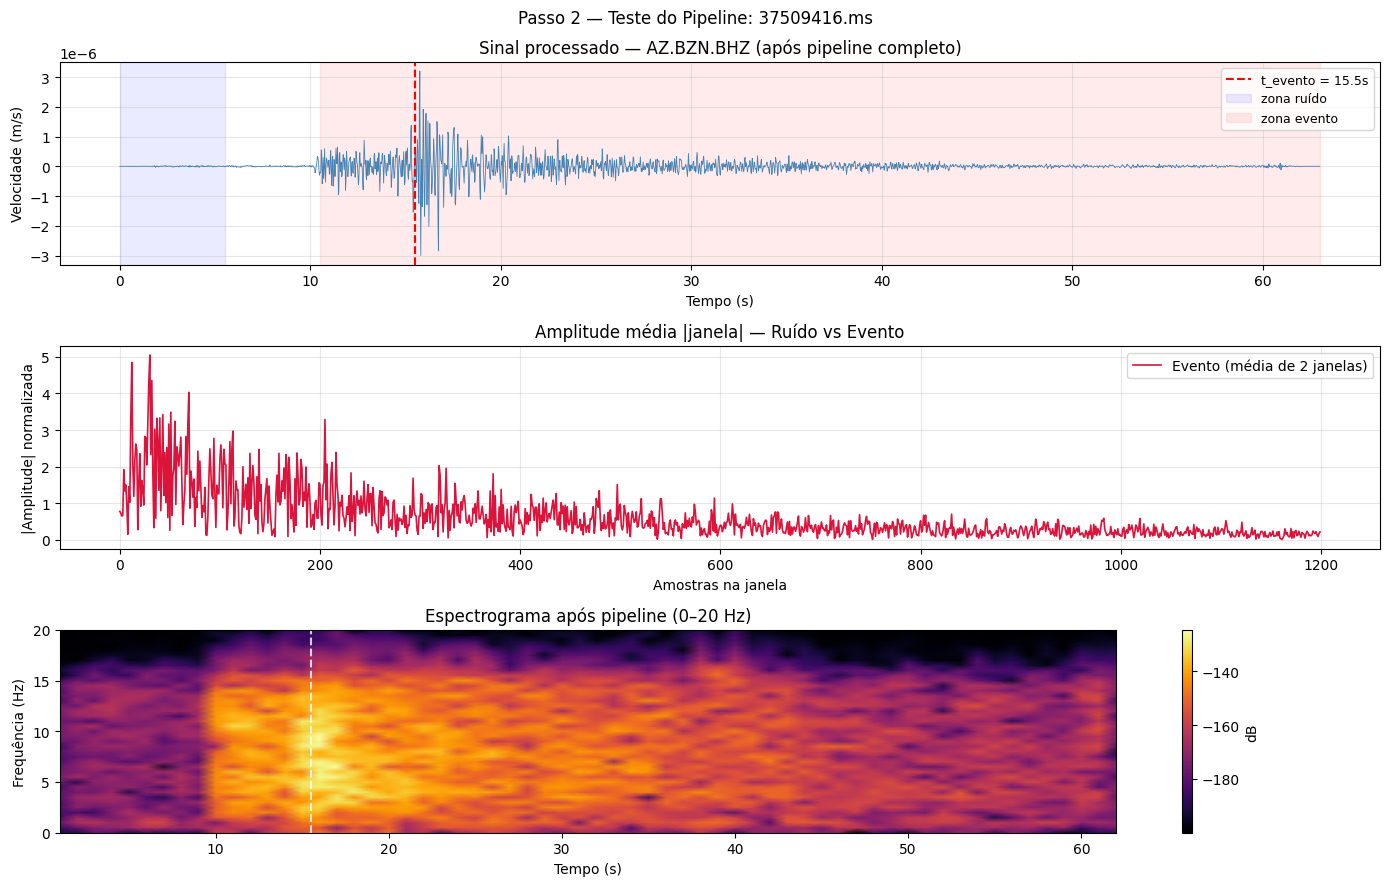


💾 Figura salva: C:\Users\vish8\OneDrive\Documentos\TCC\Trabalho\artefacts\figures\passo2_teste_pipeline.png


In [4]:
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal

# Pega o arquivo com maior razão de variância
row = df_uso.loc[df_uso['razao_var'].idxmax()]
print(f"Testando em: {row['arquivo']}")
print(f"  Estação   : {row['estacao']} | Rede: {row['rede']}")
print(f"  Razão var : {row['razao_var']:.0f}x")
print(f"  t_evento  : {row['t_evento_est']}s")

# Localiza o arquivo
caminho_ms  = row['caminho']
caminho_xml = encontrar_xml(row['rede'], row['estacao'], PASTA_XML)

if caminho_xml is None:
    print(f"❌ XML não encontrado para {row['rede']}.{row['estacao']}")
else:
    print(f"  XML       : {os.path.basename(caminho_xml)}")
    
    # Processa
    dados, sr, starttime = processar_trace(caminho_ms, caminho_xml)
    
    if dados is None:
        print("❌ Falha no processamento")
    else:
        print(f"\n✅ Pipeline OK")
        print(f"   Amostras após processamento : {len(dados)}")
        print(f"   Taxa de amostragem          : {sr} Hz")
        print(f"   Duração                     : {len(dados)/sr:.1f}s")
        print(f"   Amplitude (std)             : {dados.std():.4f} m/s")
        
        # Separar janelas
        ruido, evento = separar_janelas(dados, sr, row['t_evento_est'])
        print(f"\n   Janelas de ruído  : {len(ruido)}")
        print(f"   Janelas de evento : {len(evento)}")
        
        # ── VISUALIZAÇÃO ──────────────────────────────────────────
        fig, axes = plt.subplots(3, 1, figsize=(14, 9))
        tempo = np.arange(len(dados)) / sr
        
        # 1) Sinal processado
        ax = axes[0]
        ax.plot(tempo, dados, 'steelblue', lw=0.6)
        ax.axvline(row['t_evento_est'], color='red', ls='--', lw=1.5,
                   label=f"t_evento = {row['t_evento_est']}s")
        ax.axvspan(0, max(0, row['t_evento_est'] - 10),
                   alpha=0.08, color='blue', label='zona ruído')
        ax.axvspan(row['t_evento_est'] - 5, len(dados)/sr,
                   alpha=0.08, color='red', label='zona evento')
        ax.set_title(f'Sinal processado — {row["rede"]}.{row["estacao"]}.{CANAL_ALVO} (após pipeline completo)')
        ax.set_ylabel('Velocidade (m/s)')
        ax.set_xlabel('Tempo (s)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # 2) Comparação ruído vs evento (médias)
        ax = axes[1]
        if len(ruido) > 0:
            media_ruido = np.mean(np.abs(ruido), axis=0)
            ax.plot(media_ruido, 'steelblue', lw=1.2, label=f'Ruído (média de {len(ruido)} janelas)')
        if len(evento) > 0:
            media_evento = np.mean(np.abs(evento), axis=0)
            ax.plot(media_evento, 'crimson', lw=1.2, label=f'Evento (média de {len(evento)} janelas)')
        ax.set_title('Amplitude média |janela| — Ruído vs Evento')
        ax.set_ylabel('|Amplitude| normalizada')
        ax.set_xlabel('Amostras na janela')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 3) Espectrograma do sinal processado
        ax = axes[2]
        NFFT = int(2 * sr)
        f_s, t_s, Sxx = scipy_signal.spectrogram(dados, fs=sr, nperseg=NFFT, noverlap=NFFT//2)
        im = ax.pcolormesh(t_s, f_s, 10*np.log10(Sxx + 1e-20),
                           shading='gouraud', cmap='inferno')
        ax.set_ylim([0, 20])
        ax.axvline(row['t_evento_est'], color='white', ls='--', lw=1.5, alpha=0.8)
        ax.set_title('Espectrograma após pipeline (0–20 Hz)')
        ax.set_ylabel('Frequência (Hz)')
        ax.set_xlabel('Tempo (s)')
        plt.colorbar(im, ax=ax, label='dB')
        
        plt.suptitle(f"Passo 2 — Teste do Pipeline: {row['arquivo']}", fontsize=12)
        plt.tight_layout()
        
        fig_path = os.path.join(PASTA_PROJETO, "figures", "passo2_teste_pipeline.png")
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n💾 Figura salva: {fig_path}")


In [5]:
all_noise  = []   # lista de arrays (n_janelas, n_amostras)
all_events = []   # lista de arrays (n_janelas, n_amostras)
metadados  = []   # rastreabilidade: de onde veio cada janela

erros = []
n_amostras_janela = int(JANELA_SEG * SR_ALVO)

print(f"Processando {len(df_uso)} arquivos...")
print(f"Janelas de {JANELA_SEG}s = {n_amostras_janela} amostras")
print("-" * 70)

for i, row in df_uso.iterrows():
    arquivo = row['arquivo']
    
    # Localizar XML
    caminho_xml = encontrar_xml(row['rede'], row['estacao'], PASTA_XML)
    if caminho_xml is None:
        erros.append({'arquivo': arquivo, 'motivo': 'XML não encontrado'})
        print(f"  ❌ {arquivo:35s} XML não encontrado")
        continue
    
    # Processar
    dados, sr, starttime = processar_trace(row['caminho'], caminho_xml)
    if dados is None:
        erros.append({'arquivo': arquivo, 'motivo': 'Falha no pipeline'})
        print(f"  ❌ {arquivo:35s} Falha no pipeline")
        continue
    
    # Verificar duração mínima
    duracao = len(dados) / sr
    if duracao < JANELA_SEG * 2:
        erros.append({'arquivo': arquivo, 'motivo': 'Sinal muito curto'})
        print(f"  ⚠️  {arquivo:35s} Sinal muito curto ({duracao:.0f}s)")
        continue
    
    # Separar janelas
    ruido, evento = separar_janelas(dados, sr, row['t_evento_est'])
    
    if len(ruido) == 0 and len(evento) == 0:
        erros.append({'arquivo': arquivo, 'motivo': 'Nenhuma janela gerada'})
        print(f"  ⚠️  {arquivo:35s} Nenhuma janela gerada")
        continue
    
    # Verificar shape correto
    if len(ruido) > 0 and ruido.shape[1] != n_amostras_janela:
        erros.append({'arquivo': arquivo, 'motivo': f'Shape errado: {ruido.shape}'})
        continue
    
    if len(ruido)  > 0: all_noise.append(ruido)
    if len(evento) > 0: all_events.append(evento)
    
    # Metadados para rastreabilidade
    metadados.append({
        'arquivo'     : arquivo,
        'rede'        : row['rede'],
        'estacao'     : row['estacao'],
        'canal'       : CANAL_ALVO,
        'razao_var'   : float(row['razao_var']),
        't_evento'    : float(row['t_evento_est']),
        'n_ruido'     : int(len(ruido)),
        'n_evento'    : int(len(evento)),
        'xml'         : os.path.basename(caminho_xml),
    })
    
    print(f"  ✅ {arquivo:35s} | ruído: {len(ruido):3d} | evento: {len(evento):3d}")

# Concatenar tudo
if all_noise:
    X_noise = np.concatenate(all_noise, axis=0)
else:
    X_noise = np.empty((0, n_amostras_janela), dtype=np.float32)

if all_events:
    X_events = np.concatenate(all_events, axis=0)
else:
    X_events = np.empty((0, n_amostras_janela), dtype=np.float32)

print()
print("=" * 70)
print(f"✅ Processamento concluído")
print(f"   Arquivos processados : {len(metadados)}")
print(f"   Erros                : {len(erros)}")
print(f"   Janelas de ruído     : {len(X_noise):,}")
print(f"   Janelas de evento    : {len(X_events):,}")
print(f"   Shape ruído          : {X_noise.shape}")
print(f"   Shape evento         : {X_events.shape}")


Processando 22 arquivos...
Janelas de 30.0s = 1200 amostras
----------------------------------------------------------------------
  ✅ 37509232.ms                         | ruído:   0 | evento:   1
  ✅ 37509240.ms                         | ruído:   0 | evento:   2
  ⚠️  37509256.ms                         Nenhuma janela gerada
  ✅ 37509264.ms                         | ruído:   0 | evento:   1
  ✅ 37509272.ms                         | ruído:   0 | evento:   1
  ✅ 37509296.ms                         | ruído:   1 | evento:   0
  ✅ 37509320.ms                         | ruído:   0 | evento:   3
  ✅ 37509328.ms                         | ruído:   0 | evento:   1
  ✅ 37509336.ms                         | ruído:   0 | evento:   1
  ✅ 37509352.ms                         | ruído:   0 | evento:   2
  ⚠️  37509368.ms                         Nenhuma janela gerada
  ✅ 37509376.ms                         | ruído:   0 | evento:   2
  ✅ 37509384.ms                         | ruído:   0 | evento:   2
  ✅ 

## 6. Divisão treino / validação / teste

**Regra de ouro para séries temporais:** a divisão deve respeitar a ordem temporal.
Nunca embaralhe antes de dividir.

Para o autoencoder, usamos só janelas de ruído no treino.
As janelas de evento ficam reservadas para avaliação.


In [6]:
from sklearn.model_selection import train_test_split

# ── Divisão do ruído: 70% treino, 15% validação, 15% teste
# Mantendo ordem temporal (sem shuffle)
n_noise = len(X_noise)
n_train = int(n_noise * 0.70)
n_val   = int(n_noise * 0.15)

X_train_noise = X_noise[:n_train]
X_val_noise   = X_noise[n_train : n_train + n_val]
X_test_noise  = X_noise[n_train + n_val:]

# ── Divisão do evento: 80% teste, 20% validação
# (eventos usados para avaliar, não para treinar)
n_events = len(X_events)
n_val_ev = int(n_events * 0.20)

X_val_events  = X_events[:n_val_ev]
X_test_events = X_events[n_val_ev:]

print("Divisão do dataset:")
print(f"  Ruído  — treino    : {len(X_train_noise):,} janelas")
print(f"  Ruído  — validação : {len(X_val_noise):,} janelas")
print(f"  Ruído  — teste     : {len(X_test_noise):,} janelas")
print(f"  Evento — validação : {len(X_val_events):,} janelas")
print(f"  Evento — teste     : {len(X_test_events):,} janelas")
print()
print("📌 Conexão com o paper:")
print("   Treino   → autoencoder aprende o padrão do ruído")
print("   Validação → monitora overfitting durante o treino")
print("   Teste     → avaliação final (jamais visto durante treino)")


Divisão do dataset:
  Ruído  — treino    : 1 janelas
  Ruído  — validação : 0 janelas
  Ruído  — teste     : 1 janelas
  Evento — validação : 6 janelas
  Evento — teste     : 24 janelas

📌 Conexão com o paper:
   Treino   → autoencoder aprende o padrão do ruído
   Validação → monitora overfitting durante o treino
   Teste     → avaliação final (jamais visto durante treino)


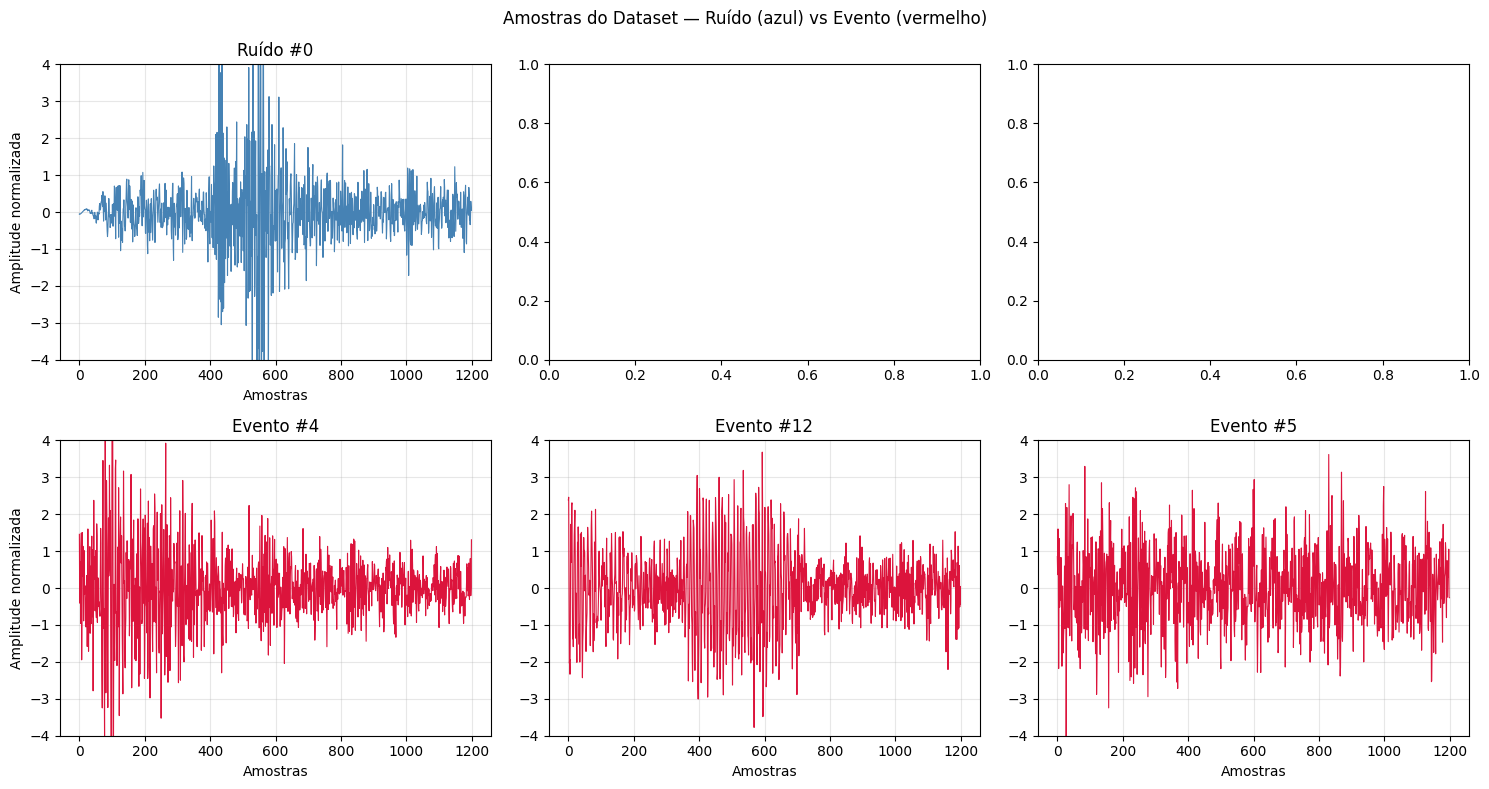

Estatísticas comparativas:
                                 Ruído        Evento
----------------------------------------------------
  Std médio                     1.0000        1.0000
  Max abs médio                12.6600        5.8553
  Kurtosis médio               34.2488        8.7455

💡 Interpretação:
   Std     : após z-score, ambos devem ser ≈1.0 (normalizado)
   Max abs : evento deve ser maior (picos extremos das ondas)
   Kurtosis: evento > ruído indica caudas pesadas (picos sísmicos)


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ── Linha 1: exemplos de janelas ──────────────────────────────────
n_exemplos = min(3, len(X_train_noise))
for j in range(n_exemplos):
    idx = np.random.randint(len(X_train_noise))
    axes[0, j].plot(X_train_noise[idx], 'steelblue', lw=0.8)
    axes[0, j].set_title(f'Ruído #{idx}')
    axes[0, j].set_ylim([-4, 4])
    axes[0, j].grid(True, alpha=0.3)
    axes[0, j].set_xlabel('Amostras')
    if j == 0: axes[0, j].set_ylabel('Amplitude normalizada')

# ── Linha 2: exemplos de eventos ─────────────────────────────────
n_ev = min(3, len(X_test_events))
for j in range(n_ev):
    idx = np.random.randint(len(X_test_events))
    axes[1, j].plot(X_test_events[idx], 'crimson', lw=0.8)
    axes[1, j].set_title(f'Evento #{idx}')
    axes[1, j].set_ylim([-4, 4])
    axes[1, j].grid(True, alpha=0.3)
    axes[1, j].set_xlabel('Amostras')
    if j == 0: axes[1, j].set_ylabel('Amplitude normalizada')

plt.suptitle('Amostras do Dataset — Ruído (azul) vs Evento (vermelho)', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(PASTA_PROJETO, "figures", "passo2_dataset_amostras.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Estatísticas comparativas ────────────────────────────────────
print("Estatísticas comparativas:")
print(f"{'':25s} {'Ruído':>12s}  {'Evento':>12s}")
print("-" * 52)
for nome, arr in [("Std médio", None), ("Max abs médio", None),
                  ("Kurtosis médio", None)]:
    if arr is None:
        std_r   = np.std(X_train_noise,  axis=1).mean()
        std_e   = np.std(X_test_events, axis=1).mean() if len(X_test_events) > 0 else 0
        max_r   = np.max(np.abs(X_train_noise),  axis=1).mean()
        max_e   = np.max(np.abs(X_test_events), axis=1).mean() if len(X_test_events) > 0 else 0
        kurt_r  = np.mean([(((x - x.mean())/x.std())**4).mean() for x in X_train_noise[:100]])
        kurt_e  = np.mean([(((x - x.mean())/x.std())**4).mean() for x in X_test_events[:100]]) if len(X_test_events) > 0 else 0
        
        print(f"  {'Std médio':23s} {std_r:>12.4f}  {std_e:>12.4f}")
        print(f"  {'Max abs médio':23s} {max_r:>12.4f}  {max_e:>12.4f}")
        print(f"  {'Kurtosis médio':23s} {kurt_r:>12.4f}  {kurt_e:>12.4f}")
        break

print()
print("💡 Interpretação:")
print("   Std     : após z-score, ambos devem ser ≈1.0 (normalizado)")
print("   Max abs : evento deve ser maior (picos extremos das ondas)")
print("   Kurtosis: evento > ruído indica caudas pesadas (picos sísmicos)")


In [8]:
# ── Salvar janelas ──────────────────────────────────────────────
noise_path  = os.path.join(PASTA_WINDOWS, "windows_noise.npz")
events_path = os.path.join(PASTA_WINDOWS, "windows_events.npz")

np.savez_compressed(
    noise_path,
    X_train = X_train_noise,
    X_val   = X_val_noise,
    X_test  = X_test_noise,
)

np.savez_compressed(
    events_path,
    X_val   = X_val_events,
    X_test  = X_test_events,
)

# ── Salvar metadados (MLOps — rastreabilidade) ───────────────────
info = {
    "versao"            : "1.0",
    "data_geracao"      : str(np.datetime64('today')),
    "parametros": {
        "canal"         : CANAL_ALVO,
        "sr_hz"         : SR_ALVO,
        "janela_seg"    : JANELA_SEG,
        "n_amostras"    : n_amostras_janela,
        "sobreposicao"  : SOBREPOSICAO,
        "margem_seg"    : MARGEM_SEG,
        "freq_min"      : FREQ_MIN,
        "freq_max"      : FREQ_MAX,
        "output_resp"   : OUTPUT_RESP,
    },
    "dataset": {
        "n_arquivos"        : len(metadados),
        "n_train_noise"     : int(len(X_train_noise)),
        "n_val_noise"       : int(len(X_val_noise)),
        "n_test_noise"      : int(len(X_test_noise)),
        "n_val_events"      : int(len(X_val_events)),
        "n_test_events"     : int(len(X_test_events)),
    },
    "arquivos_processados": metadados
}

info_path = os.path.join(PASTA_WINDOWS, "dataset_info.json")
with open(info_path, 'w', encoding='utf-8') as f:
    json.dump(info, f, indent=2, ensure_ascii=False)

# ── Verificar integridade ────────────────────────────────────────
check = np.load(noise_path)
print("✅ Dataset salvo e verificado")
print()
print("Arquivos gerados:")
for path in [noise_path, events_path, info_path]:
    size_kb = os.path.getsize(path) / 1024
    print(f"  {os.path.basename(path):30s} {size_kb:8.1f} KB")

print()
print("Verificação de integridade:")
print(f"  X_train shape: {check['X_train'].shape}")
print(f"  X_val shape  : {check['X_val'].shape}")
print(f"  X_test shape : {check['X_test'].shape}")
print()
print("=" * 60)
print("🚀 PASSO 2 CONCLUÍDO — Dataset pronto para os modelos")
print()
print("Próximo passo: Passo 3 — STA/LTA avaliado com métricas")
print("(Primeira linha da tabela comparativa do paper)")


✅ Dataset salvo e verificado

Arquivos gerados:
  windows_noise.npz                   9.4 KB
  windows_events.npz                131.3 KB
  dataset_info.json                   4.9 KB

Verificação de integridade:
  X_train shape: (1, 1200)
  X_val shape  : (0, 1200)
  X_test shape : (1, 1200)

🚀 PASSO 2 CONCLUÍDO — Dataset pronto para os modelos

Próximo passo: Passo 3 — STA/LTA avaliado com métricas
(Primeira linha da tabela comparativa do paper)
